In [22]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt


tickers = {
    "SP500": "^GSPC",
    "EUROSTOXX": "^STOXX50E",
    "EM_ASIA": "EEM",
    "EUR_BOND": "IBGM.AS",  # attention: ETF obligataire ≠ taux
    "EURUSD": "EURUSD=X",
    "GOLD": "GC=F"
}

data = yf.download(list(tickers.values()), start="2018-01-01", end="2025-12-31")["Close"]
data.columns = tickers.keys()

print(data.head())
#print(data.isna().sum())



[*********************100%***********************]  6 of 6 completed

                SP500  EUROSTOXX      EM_ASIA    EUR_BOND       EURUSD  \
Date                                                                     
2018-01-01        NaN   1.200495          NaN         NaN          NaN   
2018-01-02  39.983299   1.201158  1313.699951  190.856918  2695.810059   
2018-01-03  40.366405   1.206345  1316.199951  191.212616  2713.060059   
2018-01-04  40.566273   1.201043  1319.400024  191.604828  2723.989990   
2018-01-05  40.916058   1.206884  1320.300049  191.595734  2743.149902   

                   GOLD  
Date                     
2018-01-01          NaN  
2018-01-02          NaN  
2018-01-03  3509.879883  
2018-01-04  3568.879883  
2018-01-05  3607.629883  


In [23]:
# calculate daily log returns
returns1 = (data / data.shift(1)).dropna() # simple returns
returns2 = np.log(data / data.shift(1)).dropna() # log returns

print("Daily returns:")
print(returns1.head())

print("Daily log returns:")
print(returns2.head())


Daily returns:
               SP500  EUROSTOXX   EM_ASIA  EUR_BOND    EURUSD      GOLD
Date                                                                   
2018-01-04  1.004951   0.995604  1.002431  1.002051  1.004029  1.016810
2018-01-05  1.008623   1.004864  1.000682  0.999953  1.007034  1.010858
2018-01-08  1.000000   0.997400  0.998712  1.001476  1.001662  1.002445
2018-01-09  0.998372   0.994434  0.994767  0.997528  1.001303  1.001775
2018-01-10  0.993680   0.996564  1.004346  0.998856  0.998888  0.996401
Daily log returns:
               SP500  EUROSTOXX   EM_ASIA  EUR_BOND    EURUSD      GOLD
Date                                                                   
2018-01-04  0.004939  -0.004406  0.002428  0.002049  0.004021  0.016670
2018-01-05  0.008586   0.004852  0.000682 -0.000047  0.007009  0.010799
2018-01-08  0.000000  -0.002603 -0.001288  0.001474  0.001661  0.002442
2018-01-09 -0.001630  -0.005582 -0.005247 -0.002475  0.001302  0.001774
2018-01-10 -0.006340  -0.00344

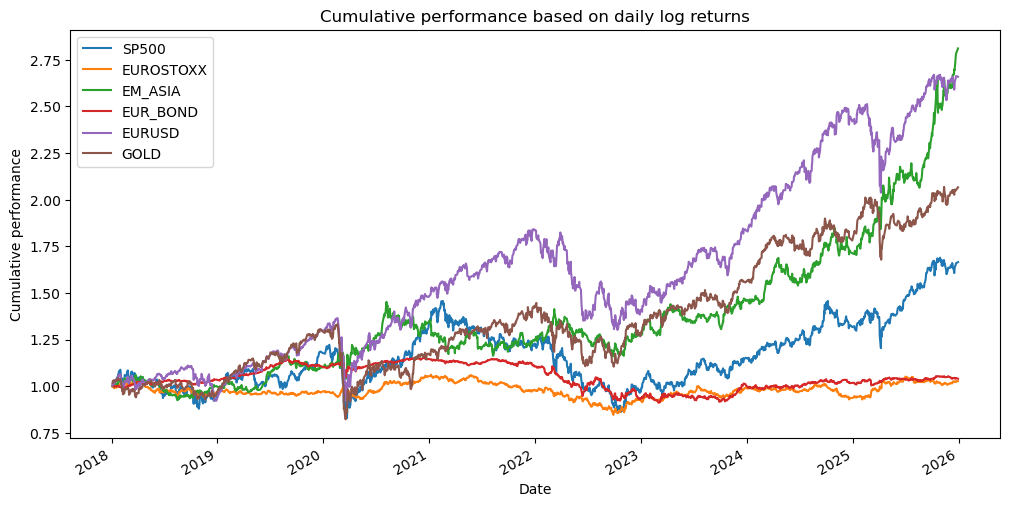

In [24]:
# cumulative performance from daily log returns
cum_assets = np.exp(returns2.cumsum())
cum_assets.plot(figsize=(12, 6))
plt.title("Cumulative performance based on daily log returns")
plt.xlabel("Date")
plt.ylabel("Cumulative performance")
plt.legend()
plt.show()

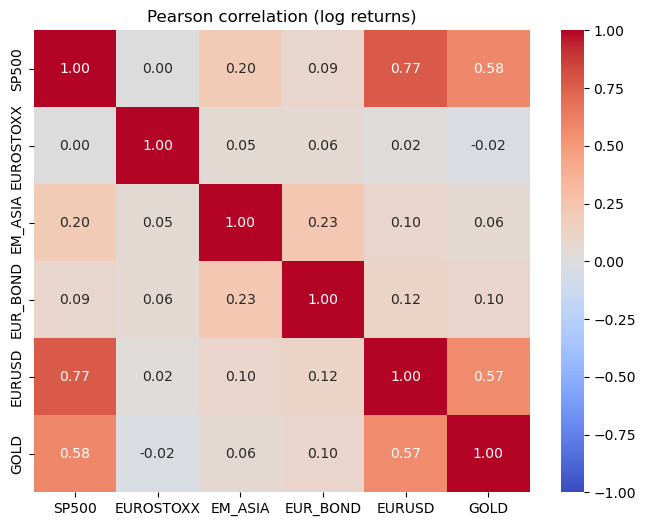

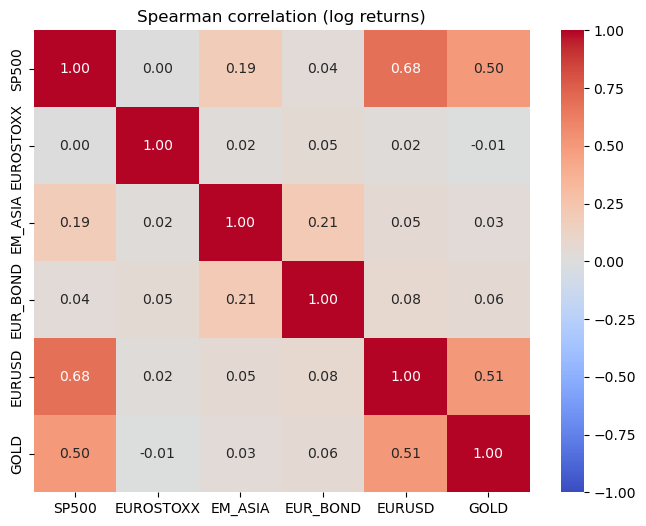

In [25]:
corr_p = returns2.corr()
corr_s = returns2.corr(method="spearman")

# heatmap Pearson
plt.figure(figsize=(8, 6))
sns.heatmap(corr_p, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Pearson correlation (log returns)")
plt.show()

# heatmap Spearman
plt.figure(figsize=(8, 6))
sns.heatmap(corr_s, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Spearman correlation (log returns)")
plt.show()

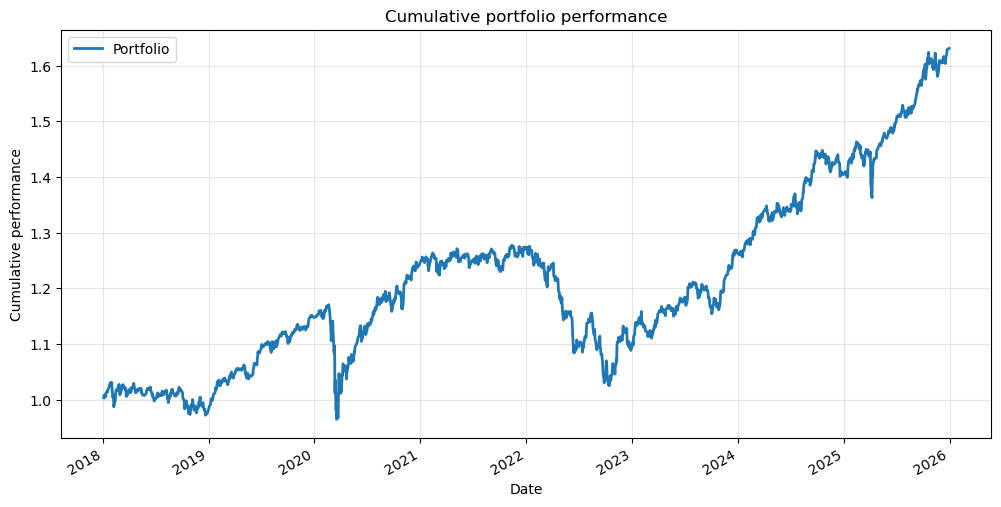

In [26]:
portfolio = {'Stocks': ['SP500', 'EUROSTOXX', 'EM_ASIA'],'Bonds': ['EUR_BOND'],'Currencies': ['EURUSD'],'Commodities': ['GOLD']}
weighting = {'Stocks': 0.4, 'Bonds': 0.3, 'Currencies': 0.2, 'Commodities': 0.1}

weights = {}
for cls, assets in portfolio.items():
    for asset in assets:
        weights[asset] = weighting[cls] / len(assets)
weights = pd.Series(weights) # convertion in serties for easier manipulation
#print("Poids par actif :\n", weights)
#print("Total poids:", weights.sum())

# daily portfolio returns and cumulative portfolio performance
#print(returns2)
#print(returns2[weights.index])
#print(returns2 * weights)
port_returns = (returns2 * weights).sum(axis=1)
port_cum = np.exp(port_returns.cumsum())

plt.figure(figsize=(12, 6))
port_cum.plot(label='Portfolio', linewidth=2)
plt.title("Cumulative portfolio performance")
plt.xlabel("Date")
plt.ylabel("Cumulative performance")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [27]:
# Calculate key portfolio metrics
annual_return = port_returns.mean() * 252
annual_vol = port_returns.std() * np.sqrt(252)
sharpe_ratio = annual_return / annual_vol
max_drawdown = (port_cum / port_cum.cummax() - 1).min()

print(f"Annual Return: {annual_return:.2%}")
print(f"Annual Volatility: {annual_vol:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")

Annual Return: 6.68%
Annual Volatility: 8.88%
Sharpe Ratio: 0.75
Max Drawdown: -19.73%


In [28]:
benchmark_returns = returns2['SP500']  # indice
cov_matrix = np.cov(port_returns, benchmark_returns) # covariance matrix
beta_port = cov_matrix[0,1] / cov_matrix[1,1] # beta formula

print(f"Portfolio Beta vs SP500: {beta_port:.3f}")


Portfolio Beta vs SP500: 0.359


Value at Risk (95%): -0.79%
Value at Risk (99%): -1.51%


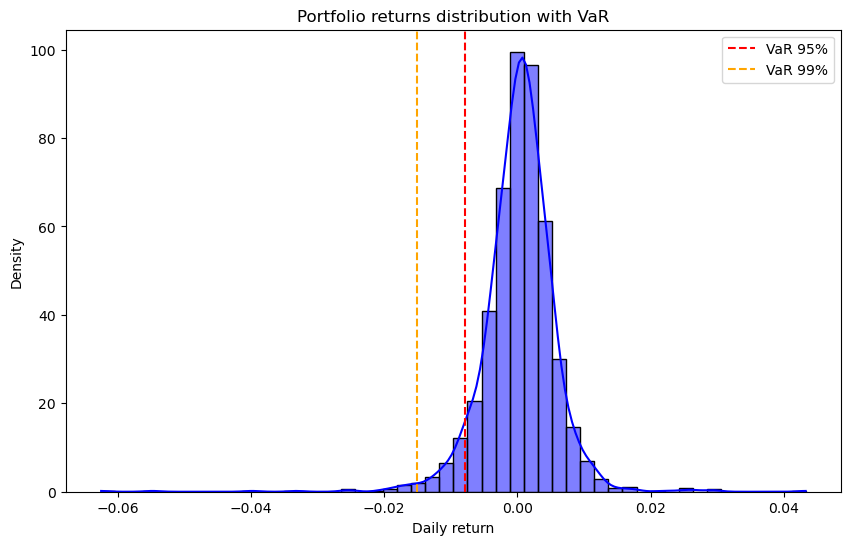

In [ ]:
# Historical Simulation VaR calculation 
confidence_level1 = 0.95
confidence_level2 = 0.99
var_95 = np.percentile(port_returns, (1 - confidence_level1) * 100)
var_99 = np.percentile(port_returns, (1 - confidence_level2) * 100)
print(f"VAR (95%): {var_95:.2%}")
print(f"VAR (99%): {var_99:.2%}")

plt.figure(figsize=(10, 6))
sns.histplot(port_returns, bins=50, kde=True, color='blue', stat='density')
plt.axvline(var_95, color='red', linestyle='--', label='VaR 95%')
plt.axvline(var_99, color='orange', linestyle='--', label='VaR 99%')
plt.title("Portfolio returns distribution with VaR")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.legend()
plt.show()

Parametric VAR (95%): -0.89%
Parametric VAR (99%): -1.28%


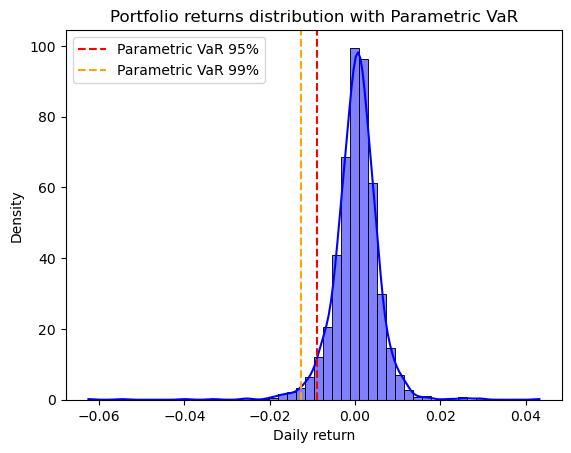

In [ ]:
# Parametric VAR calculation
confidence_level1 = 0.95
confidence_level2 = 0.99

mean_return = port_returns.mean()
std_return = port_returns.std()

z_95 = norm.ppf(1 - confidence_level1)
z_99 = norm.ppf(1 - confidence_level2)
var_95_param = mean_return + z_95 * std_return
var_99_param = mean_return + z_99 * std_return

print(f"Parametric VAR (95%): {var_95_param:.2%}")
print(f"Parametric VAR (99%): {var_99_param:.2%}")
sns.histplot(port_returns, bins=50, kde=True, color='blue', stat='density')
plt.axvline(var_95_param, color='red', linestyle='--', label='Parametric VaR 95%')
plt.axvline(var_99_param, color='orange', linestyle='--', label='Parametric VaR 99%')
plt.title("Portfolio returns distribution with Parametric VaR")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.legend()


Monte Carlo VaR (95%): -0.89%
Monte Carlo VaR (99%): -1.26%


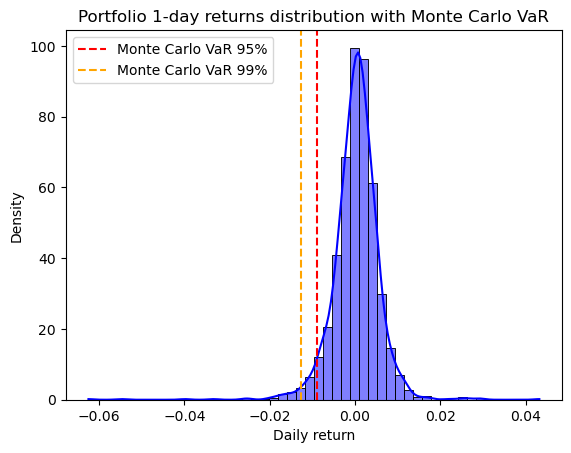

Monte Carlo VaR 10j (95%): -2.71%
Monte Carlo VaR 10j (99%): -3.93%


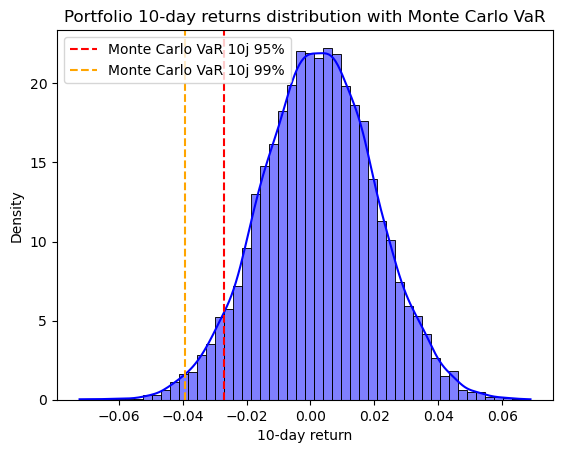

In [47]:
# Monte Carlo VaR calculation
num_simulations = 10000
confidence_level1 = 0.95
confidence_level2 = 0.99

mu = port_returns.mean()
sigma = port_returns.std()

# simulation Monte Carlo (normal distribution) 1 day
sim_returns = np.random.normal(mu, sigma, num_simulations)

# VaR 
var_95_mc = np.percentile(sim_returns, (1 - confidence_level1) * 100)
var_99_mc = np.percentile(sim_returns, (1 - confidence_level2) * 100)

print(f"Monte Carlo VaR (95%): {var_95_mc:.2%}")
print(f"Monte Carlo VaR (99%): {var_99_mc:.2%}")
sns.histplot(port_returns, bins=50, kde=True, color='blue', stat='density')
plt.axvline(var_95_mc, color='red', linestyle='--', label='Monte Carlo VaR 95%')
plt.axvline(var_99_mc, color='orange', linestyle='--', label='Monte Carlo VaR 99%')
plt.title("Portfolio 1-day returns distribution with Monte Carlo VaR")
plt.xlabel("Daily return")
plt.ylabel("Density")
plt.legend()
plt.show()

# simulation Monte Carlo (normal distribution) 10 days
T = 10

sim_paths = np.random.normal(mu, sigma, size=(num_simulations, T))
cum_log_returns = sim_paths.sum(axis=1)

var_95_mc_10 = np.percentile(cum_log_returns, 5)
var_99_mc_10 = np.percentile(cum_log_returns, 1)

print(f"Monte Carlo VaR 10j (95%): {var_95_mc_10:.2%}")
print(f"Monte Carlo VaR 10j (99%): {var_99_mc_10:.2%}")
sns.histplot(cum_log_returns, bins=50, kde=True, color='blue', stat='density')        
plt.axvline(var_95_mc_10, color='red', linestyle='--', label='Monte Carlo VaR 10j 95%')
plt.axvline(var_99_mc_10, color='orange', linestyle='--', label='Monte Carlo VaR 10j 99%')
plt.title("Portfolio 10-day returns distribution with Monte Carlo VaR")
plt.xlabel("10-day return")
plt.ylabel("Density")
plt.legend()
plt.show()

